
Starting execution for mode: _gaussian (200 realizations)
Computing base EOS and TOV family for case1...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case2...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case3...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case4...
  Evaluating 200 subsets...
Generating Line Plot for _gaussian...
  -> Dropped 27 extreme log-likelihood outliers to stabilize calculations.


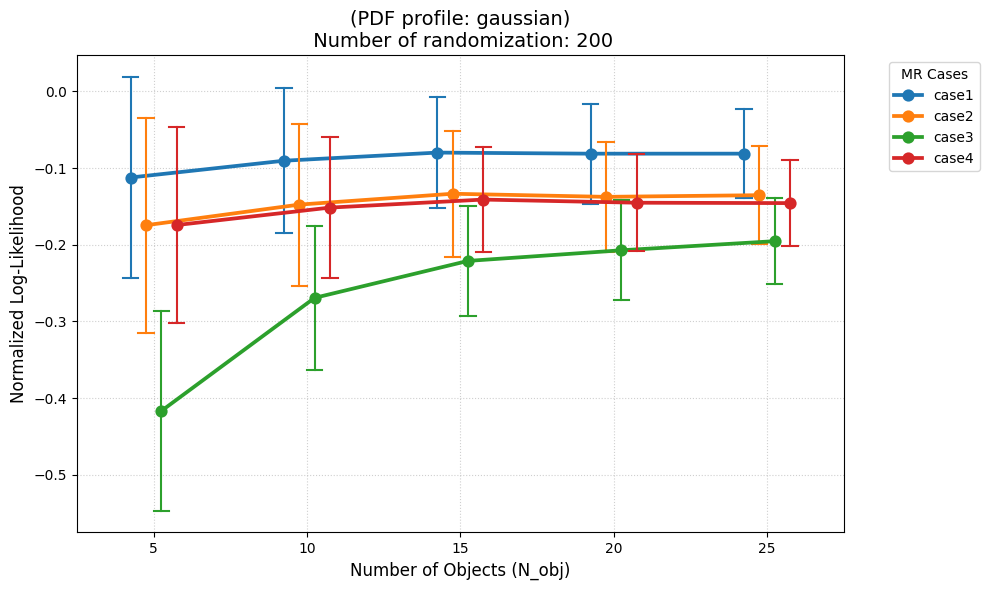

Successfully saved likelihood_lineplot_vs_N_obj_gaussian.png

Starting execution for mode: _corr_skew (200 realizations)
Computing base EOS and TOV family for case1...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case2...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case3...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case4...
  Evaluating 200 subsets...
Generating Line Plot for _corr_skew...
  -> Dropped 303 extreme log-likelihood outliers to stabilize calculations.


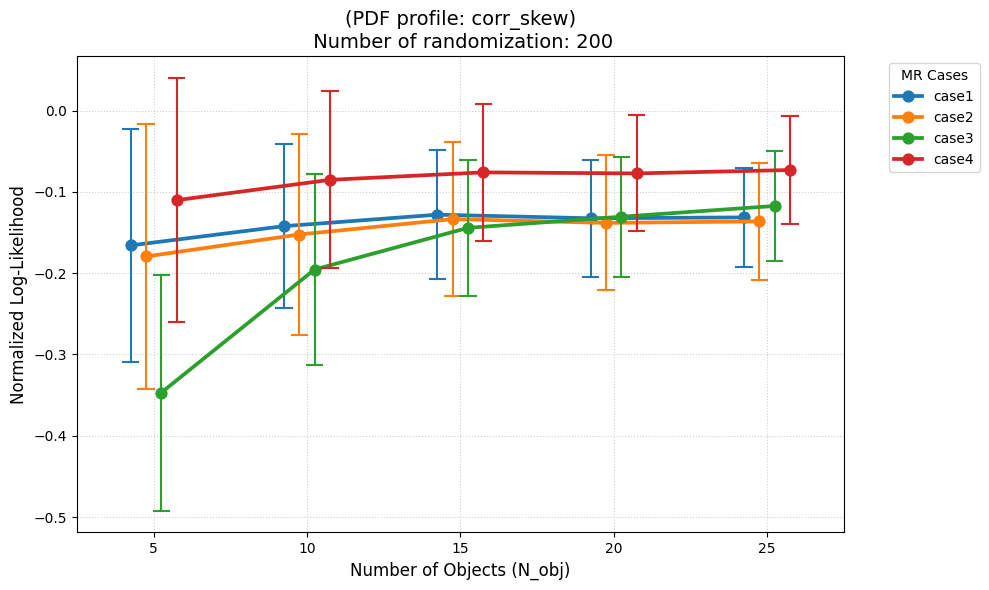

Successfully saved likelihood_lineplot_vs_N_obj_corr_skew.png

Starting execution for mode: _sys (200 realizations)
Computing base EOS and TOV family for case1...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case2...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case3...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case4...
  Evaluating 200 subsets...
Generating Line Plot for _sys...
  -> Dropped 51 extreme log-likelihood outliers to stabilize calculations.


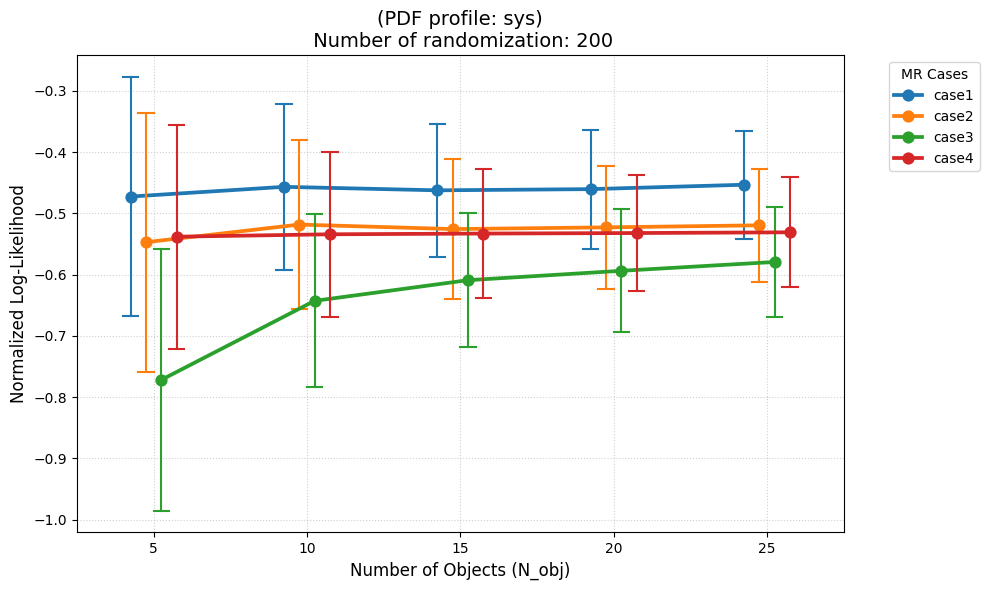

Successfully saved likelihood_lineplot_vs_N_obj_sys.png

Starting execution for mode: _sys_corr_skew (200 realizations)
Computing base EOS and TOV family for case1...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case2...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case3...
  Evaluating 200 subsets...
Computing base EOS and TOV family for case4...
  Evaluating 200 subsets...
Generating Line Plot for _sys_corr_skew...
  -> Dropped 338 extreme log-likelihood outliers to stabilize calculations.


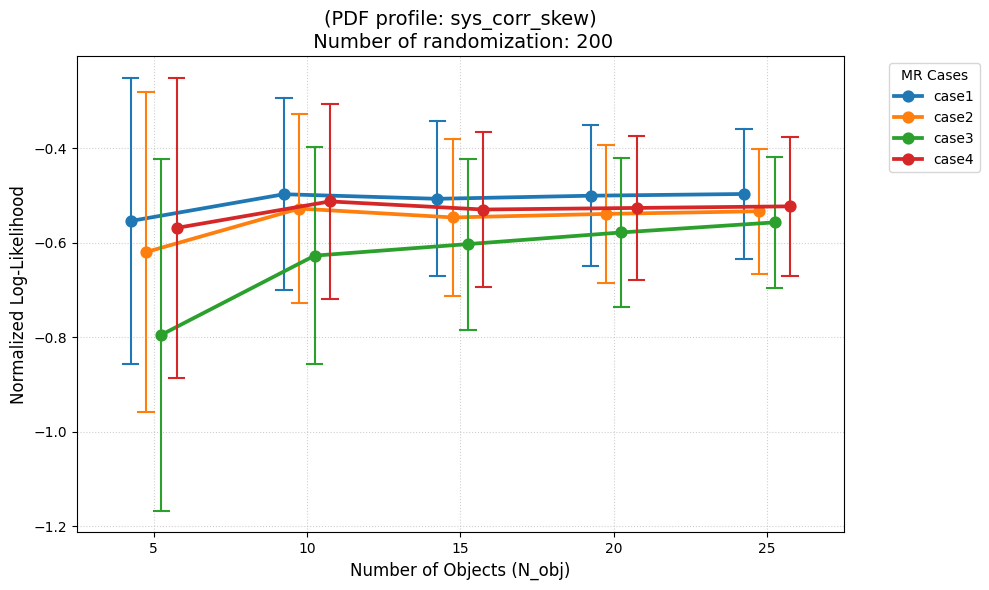

Successfully saved likelihood_lineplot_vs_N_obj_sys_corr_skew.png


In [5]:
import os
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from jax import random, config
config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

from jesterTOV import utils
from jesterTOV.eos.metamodel import MetaModel_with_CSE_EOS_model
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver
from jesterTOV.tov.data_classes import EOSData

from cases import get_case_data, parse_input_data
from likelihood import SkewedCorrelatedFlow, MockMRLikelihood

def main():
    cases_to_run = ["case1", "case2", "case3", "case4"]
    N_obj_list = [5, 10, 15, 20, 25]
    N_realizations = 200  

    experiment_modes = [
        {"sys": False, "corr": False, "skew": False},
        {"sys": False, "corr": True,  "skew": True},
        {"sys": True,  "corr": False, "skew": False},
        {"sys": True,  "corr": True,  "skew": True}
    ]

    st_solver = ScalarTensorTOVSolver()
    temp_csv_path = "temp_mock_realization_200.csv"

    for mode in experiment_modes:
        sys = mode["sys"]
        corr = mode["corr"]
        skew = mode["skew"]

        toggle_str = ""
        if sys: toggle_str += "_sys"
        if corr: toggle_str += "_corr"
        if skew: toggle_str += "_skew"
        if not toggle_str: toggle_str = "_gaussian"

        print(f"\n========================================")
        print(f"Starting execution for mode: {toggle_str} (200 realizations)")
        print(f"========================================")

        results_data = []

        for case_name in cases_to_run:
            print(f"Computing base EOS and TOV family for {case_name}...")
            
            input_data_str = get_case_data(case_name)
            input_dict = parse_input_data(input_data_str)
            beta_ST = input_dict.pop("beta_ST")
            input_dict["n_CSE_8_u"] = 25.0

            eos = MetaModel_with_CSE_EOS_model(
                nmax_nsat=25.0, nb_CSE=8, nmin_MM_nsat=0.75, ndat_metamodel=80, ndat_CSE=70
            )
            eos_output = eos.construct_eos(input_dict)
            eos_data = EOSData(
                ns=eos_output.ns, ps=eos_output.ps, hs=eos_output.hs, 
                es=eos_output.es, dloge_dlogps=eos_output.dloge_dlogps, cs2=eos_output.cs2
            )

            tov_params = {"beta_ST": beta_ST, "phi_c": 1.0, "phi_inf_tgt": 1e-3}
            family = st_solver.construct_family(eos_data, ndat=200, min_nsat=0.1, tov_params=tov_params)
            
            mask = (family.radii < 50) & (family.radii > 5) & (family.masses > 1.2) & jnp.isfinite(family.extra["lambda_S"])
            base_masses = family.masses[mask]
            base_radii = family.radii[mask]

            split_idx = int(utils.get_MR_split_index(base_radii, base_masses))
            rad_seg1, rad_seg2 = base_radii[:split_idx], base_radii[split_idx:]
            mass_seg1, mass_seg2 = base_masses[:split_idx], base_masses[split_idx:]

            m_eos = jnp.array(base_masses)
            r_eos = jnp.array(base_radii)
            params_eval = {"masses_EOS": m_eos, "radii_EOS": r_eos}

            base_key = random.PRNGKey(42)
            keys = random.split(base_key, N_realizations)

            print(f"  Evaluating {N_realizations} subsets...")
            for idx, key in enumerate(keys):
                np.random.seed(42 + idx) 

                N_max = max(N_obj_list)
                key, subkey_u, subkey_coin, subkey_force, key_r, key_m = random.split(key, 6)
                
                if len(mass_seg2) == 0:
                    m1_min, m1_max = mass_seg1[0], mass_seg1[-1]
                    sample_masses_max = random.uniform(subkey_u, shape=(N_max,), minval=m1_min, maxval=m1_max)
                    sample_radii_max = jnp.interp(sample_masses_max, mass_seg1, rad_seg1)
                else:
                    m1_min, m1_max = mass_seg1[0], mass_seg1[-1]
                    m2_min, m2_max = mass_seg2[-1], mass_seg2[0] 
                    
                    cond = m1_min <= m2_min
                    min_a = jnp.where(cond, m1_min, m2_min)
                    max_a = jnp.where(cond, m1_max, m2_max)
                    min_b = jnp.where(cond, m2_min, m1_min)
                    max_b = jnp.where(cond, m2_max, m1_max)
                    
                    is_gap = min_b > max_a
                    width_a = max_a - min_a
                    width_b = max_b - min_b
                    
                    total_domain_width = jnp.where(is_gap, width_a + width_b, jnp.maximum(max_a, max_b) - min_a)
                    u = random.uniform(subkey_u, shape=(N_max,), minval=0.0, maxval=total_domain_width)
                    
                    mass_if_gap = jnp.where(u <= width_a, min_a + u, min_b + (u - width_a))
                    mass_if_overlap = min_a + u
                    sample_masses_max = jnp.where(is_gap, mass_if_gap, mass_if_overlap)
                    
                    r1 = jnp.interp(sample_masses_max, mass_seg1, rad_seg1)
                    r2 = jnp.interp(sample_masses_max, mass_seg2[::-1], rad_seg2[::-1])
                    
                    valid1 = (sample_masses_max >= m1_min) & (sample_masses_max <= m1_max)
                    valid2 = (sample_masses_max >= m2_min) & (sample_masses_max <= m2_max)
                    
                    coin_flip = random.bernoulli(subkey_coin, p=0.5, shape=(N_max,))
                    use_seg1 = jnp.where(valid1 & valid2, coin_flip, valid1)
                    sample_radii_max = jnp.where(use_seg1, r1, r2)
                    
                    missed_seg2 = jnp.all(use_seg1)
                    forced_m2 = random.uniform(subkey_force, shape=(), minval=m2_min, maxval=m2_max)
                    forced_r2 = jnp.interp(forced_m2, mass_seg2[::-1], rad_seg2[::-1])
                    
                    overwrite_mask = (jnp.arange(N_max) == 0) & missed_seg2
                    
                    sample_masses_max = jnp.where(overwrite_mask, forced_m2, sample_masses_max)
                    sample_radii_max = jnp.where(overwrite_mask, forced_r2, sample_radii_max)

                std_m_max = random.uniform(key_m, shape=sample_masses_max.shape, minval=0.02, maxval=0.05)
                std_r_max = random.uniform(key_r, shape=sample_radii_max.shape, minval=0.02, maxval=0.05)
                
                delta_r_max = std_r_max * sample_radii_max
                delta_m_max = std_m_max * sample_masses_max
                
                if not sys:
                    noise_r_max = jnp.zeros_like(sample_radii_max)
                    noise_m_max = jnp.zeros_like(sample_masses_max)
                else:
                    noise_r_max = random.normal(key_r, shape=sample_radii_max.shape) * delta_r_max
                    noise_m_max = random.normal(key_m, shape=sample_masses_max.shape) * delta_m_max

                sample_radii_noise_max = sample_radii_max + noise_r_max
                sample_masses_noise_max = sample_masses_max + noise_m_max

                corr_max = np.random.uniform(0, 1, size=N_max) if corr else np.zeros(N_max)
                if not skew:
                    skew_v_max = np.zeros((N_max, 2))
                else:
                    skew_v_max = np.random.uniform(-3.0, 3.0, size=(N_max, 2))

                for N_obj in N_obj_list:
                    table_data = []
                    
                    for i in range(N_obj):
                        std_m_val = delta_m_max[i]
                        std_r_val = delta_r_max[i]
                        cov_val = corr_max[i] * std_m_val * std_r_val
                        
                        table_data.append({
                            "Sample": i + 1,
                            "Mass_Center": f"{sample_masses_max[i]:.3f}",
                            "Radius_Center": f"{sample_radii_max[i]:.3f}",
                            "Mass_Center_Noise": f"{sample_masses_noise_max[i]:.3f}",
                            "Radius_Center_Noise": f"{sample_radii_noise_max[i]:.3f}",
                            "Std_Mass": f"{std_m_val:.3f}",
                            "Std_Radius": f"{std_r_val:.3f}",
                            "Covariance": f"{cov_val:.3f}",
                            "Skew_Mass": f"{skew_v_max[i, 0]:.3f}",
                            "Skew_Radius": f"{skew_v_max[i, 1]:.3f}"
                        })

                    df_params = pd.DataFrame(table_data)
                    df_params.to_csv(temp_csv_path, index=False)
                    
                    mock_likelihood = MockMRLikelihood(temp_csv_path, N_masses_evaluation=300)
                    ll_val = mock_likelihood.evaluate(params_eval)
                    
                    results_data.append({
                        "Case": case_name,
                        "N_obj": N_obj,
                        "LogLikelihood": float(ll_val)
                    })

        print(f"Generating Line Plot for {toggle_str}...")
        df_results = pd.DataFrame(results_data)
        
        clean_data = []
        for (case, nobj), group in df_results.groupby(["Case", "N_obj"]):
            Q1 = group["LogLikelihood"].quantile(0.25)
            Q3 = group["LogLikelihood"].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            mask = (group["LogLikelihood"] >= lower_bound) & (group["LogLikelihood"] <= upper_bound)
            clean_data.append(group[mask])
        
        df_cleaned = pd.concat(clean_data)
        dropped = len(df_results) - len(df_cleaned)
        if dropped > 0:
            print(f"  -> Dropped {dropped} extreme log-likelihood outliers to stabilize calculations.")
        
        plt.figure(figsize=(10, 6))
        
        ax = sns.pointplot(
            data=df_cleaned,
            x="N_obj",
            y="LogLikelihood",
            hue="Case",
            estimator=np.mean,   
            errorbar="sd",       
            dodge=0.3,           
            capsize=0.1,         
            err_kws={'linewidth': 1.5},
            markers='o',
            linestyles='-'
        )
        
        plt.title(f"(PDF profile: {toggle_str.strip('_')})\n Number of randomization: {N_realizations}", fontsize=14)
        plt.xlabel("Number of Objects (N_obj)", fontsize=12)
        plt.ylabel("Normalized Log-Likelihood", fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.6)
        
        handles, labels = ax.get_legend_handles_labels()
        n_cases = len(cases_to_run)
        plt.legend(handles[:n_cases], labels[:n_cases], title="MR Cases", bbox_to_anchor=(1.05, 1), loc='upper left')
        
        final_plot_filename = f"likelihood_lineplot_vs_N_obj{toggle_str}.png"
        plt.tight_layout()
        plt.savefig(final_plot_filename, dpi=120)
        plt.show()
        plt.close()
        print(f"Successfully saved {final_plot_filename}")

    if os.path.exists(temp_csv_path):
        os.remove(temp_csv_path)

if __name__ == "__main__":
    main()